In [ ]:
import os, sys

# Make the part3/ package importable and data/ paths resolvable from notebooks/.
ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
sys.path.insert(0, ROOT)
os.chdir(ROOT)

import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

from src.data import get_data

df = get_data()

# Exploratory Data Analysis (EDA)
## Data distribution

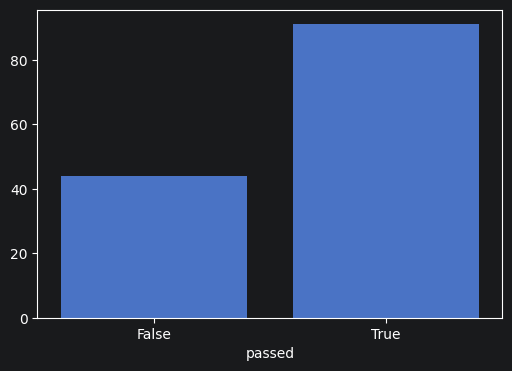

In [12]:
y = df['passed']

plt.figure(figsize=(6, 4))
sns.barplot(x=y.value_counts().index, y=y.value_counts().values)
plt.show()

## Correlation heatmap

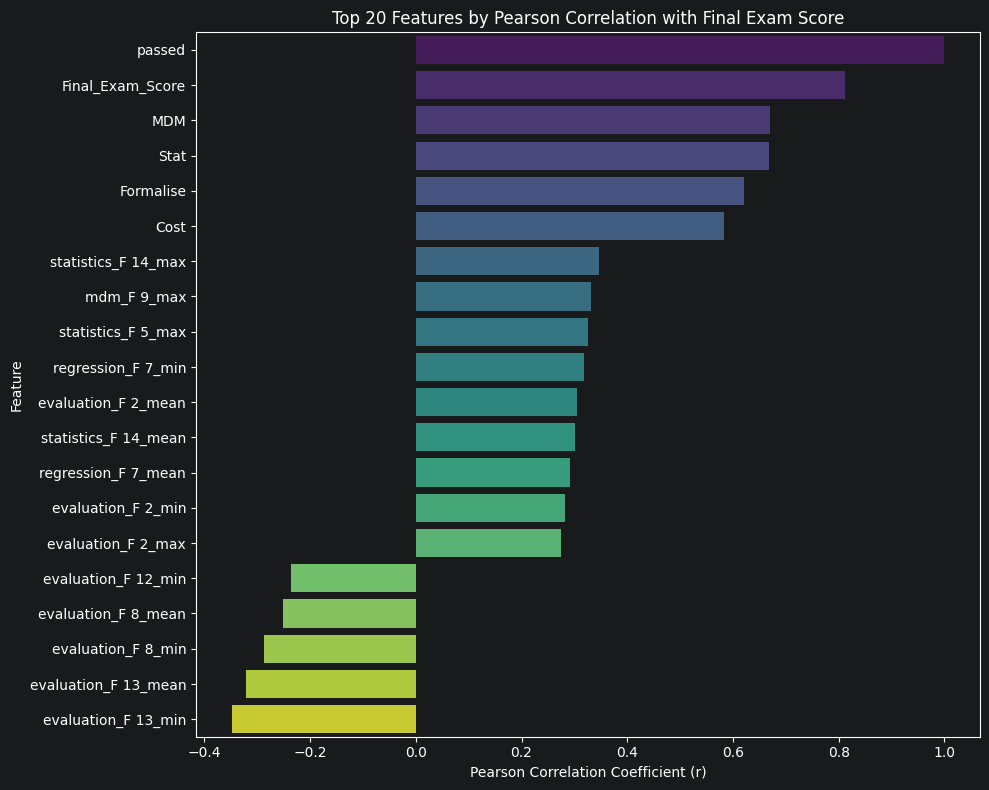

In [13]:
df = df.drop(columns=['StudentID', 'Semester'])
correlations = df.corrwith(df['passed'], method='spearman').sort_values(ascending=False)

corr_df = correlations.to_frame(name='Correlation_with_Target').reset_index()
corr_df.rename(columns={'index': 'Feature'}, inplace=True)
top_features = pd.concat([corr_df.head(15), corr_df.tail(5)])

plt.figure(figsize=(10, 8))
sns.barplot(
    x='Correlation_with_Target',
    y='Feature',
    data=top_features,
    hue='Feature',
    palette='viridis',
    legend=False
)
plt.title('Top 20 Features by Pearson Correlation with Final Exam Score')
plt.xlabel('Pearson Correlation Coefficient (r)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## UMap Visualization

C:\Users\denis\AppData\Local\Temp\ipykernel_15552\26083397.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_umap = umap.fit_transform(X.fillna(0))
C:\Users\denis\AppData\Local\pypoetry\Cache\virtualenvs\p-bi-mmi-pEZqXyKx-py3.12\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


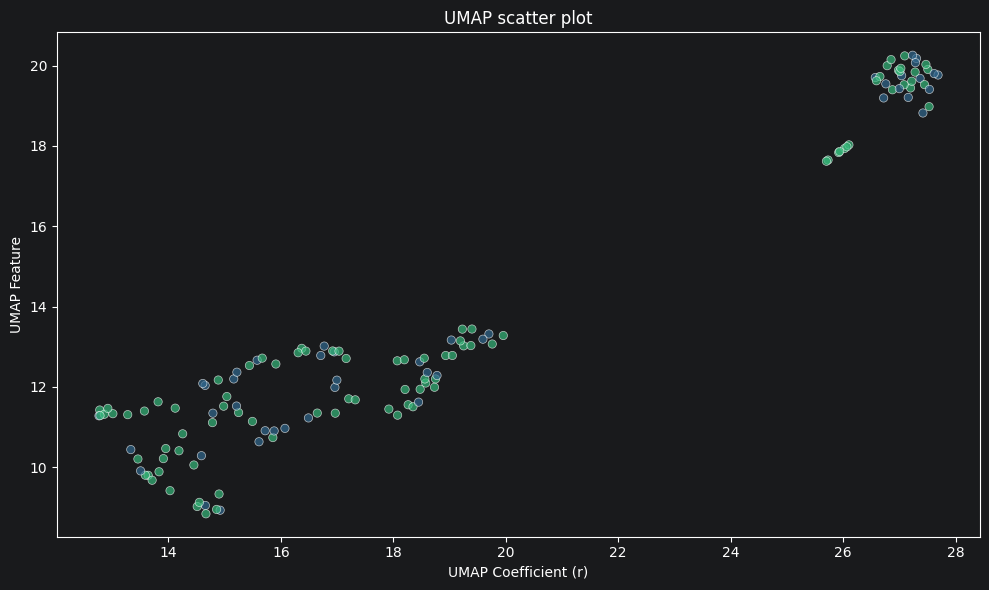

In [15]:
from umap import UMAP
import re

df = df.drop(columns=[col for col in df.columns if re.match(r'.*F\s\d+.*', col)])
X = df.drop(columns=['MDM', 'Stat', 'Formalise', 'Cost', 'Final_Exam_Score', 'passed'])
y = df['passed']

umap = UMAP(n_components=2, random_state=42)
X_umap = umap.fit_transform(X.fillna(0))

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=X_umap[:, 0],
    y=X_umap[:, 1],
    hue=y,
    palette='viridis',
    legend=False,
    alpha=0.7
)
plt.title('UMAP scatter plot')
plt.xlabel('UMAP Coefficient (r)')
plt.ylabel('UMAP Feature')
plt.tight_layout()
plt.show()

C:\Users\denis\AppData\Local\Temp\ipykernel_15552\943889398.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_pca = pca.fit_transform(X.fillna(0))


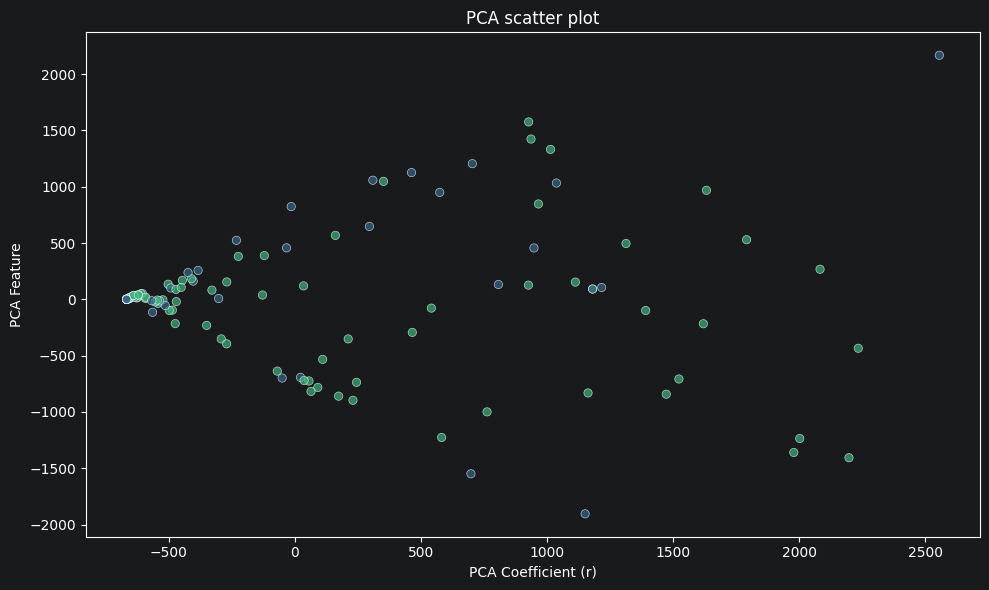

In [16]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)

X_pca = pca.fit_transform(X.fillna(0))
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=y,
    palette='viridis',
    legend=False,
    alpha=0.7
)
plt.title('PCA scatter plot')
plt.xlabel('PCA Coefficient (r)')
plt.ylabel('PCA Feature')
plt.tight_layout()
plt.show()